<a href="https://colab.research.google.com/github/emanuelpereira97/Cin-ncias-de-dados---UFRN/blob/main/atv_3_aprendizado_n_supervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [5]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
caminho = 'https://drive.google.com/uc?export=download&id=1TNjFPu8o80j4ZuJujqhOdJtoCtqVYgBX'
df = pd.read_csv(caminho, sep=None, engine="python")
df.columns = [col.strip().upper() for col in df.columns]

In [7]:
#----limpando colunas
colunas_ignorar = [
    "UNNAMED: 0",
    "ID_MUNICIP",
    "ID_UNIDADE"
]

df = df.drop(columns=colunas_ignorar, errors="ignore")
#------------------

In [8]:
#---criando idade e faixa etaria
df["DT_NOTIFIC"] = pd.to_datetime(df["DT_NOTIFIC"], errors="coerce")
df["ANO_NOTIFIC"] = df["DT_NOTIFIC"].dt.year
df["MES_NOTIFIC"] = df["DT_NOTIFIC"].dt.month
df["ANO_NASC"] = pd.to_numeric(df["ANO_NASC"], errors="coerce")
df["IDADE"] = df["ANO_NOTIFIC"] - df["ANO_NASC"]
df.loc[(df["IDADE"] < 0) | (df["IDADE"] > 120), "IDADE"] = np.nan
df["FAIXA_ETARIA"] = pd.cut(
    df["IDADE"],
    bins=[0, 12, 18, 30, 45, 60, 121],
    labels=["0-11", "12-17", "18-29", "30-44", "45-59", "60+"],
    right=False
)
#---------------

In [9]:
#------- substitui no dataset os valores numericos pelas categorias
df["SEXO"] = df["CS_SEXO"].replace({
    "M": "MASCULINO",
    "F": "FEMININO",
    "I": np.nan,
    "9": np.nan
})

df["RACA"] = df["CS_RACA"].astype(str).replace({
    "1": "BRANCA",
    "2": "PRETA",
    "3": "AMARELA",
    "4": "PARDA",
    "5": "INDIGENA",
    "9": np.nan
})

df["GESTANTE"] = df["CS_GESTANT"].astype(str).replace({
    "1": "1_TRIMESTRE",
    "2": "2_TRIMESTRE",
    "3": "3_TRIMESTRE",
    "4": "IDADE_GESTACIONAL_IGNORADA",
    "5": "NAO",
    "6": "NAO_SE_APLICA",
    "9": np.nan
})
#------------------

In [10]:
#----variaveis para modelo
df_modelo = df.dropna(subset=["IDADE", "MES_NOTIFIC"]).copy()

variaveis_numericas = ["IDADE", "MES_NOTIFIC"]
variaveis_categoricas = ["SEXO", "RACA", "GESTANTE"]

#---------

In [11]:
#----substitui calores nulos pela mediana e pela categoria de maior frequancia
#----aplica normalização para criar a matriz de variaveis
preprocessador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), variaveis_numericas),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), variaveis_categoricas)
    ]
)

X = preprocessador.fit_transform(df_modelo)
#-------------

Variância explicada: [0.31622095 0.28579207]
Variância total: 0.6020130175806448


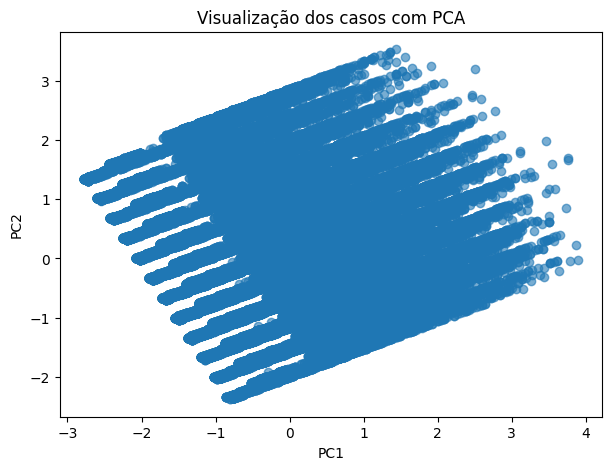

In [12]:
#----PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print("Variância explicada:", pca.explained_variance_ratio_)
print("Variância total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualização dos casos com PCA")
plt.show()
#----------

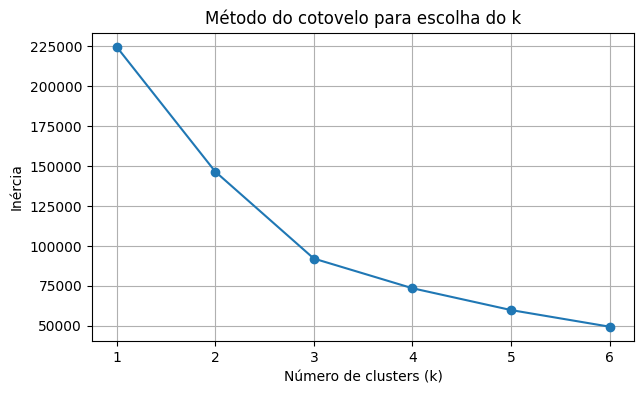

In [13]:
#----K-MEANS (descomentar para testar o met. do cotovelo)

inercias = []
valores_k = range(1, 7)

for k in valores_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        max_iter=300
    )

    kmeans.fit(X_pca)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(valores_k, inercias, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do cotovelo para escolha do k")
plt.xticks(list(valores_k))
plt.grid(True)
plt.show()


Distribuição dos clusters do K-Means:
CLUSTER_KMEANS
1    43320
2    35829
0    29458
Name: count, dtype: int64


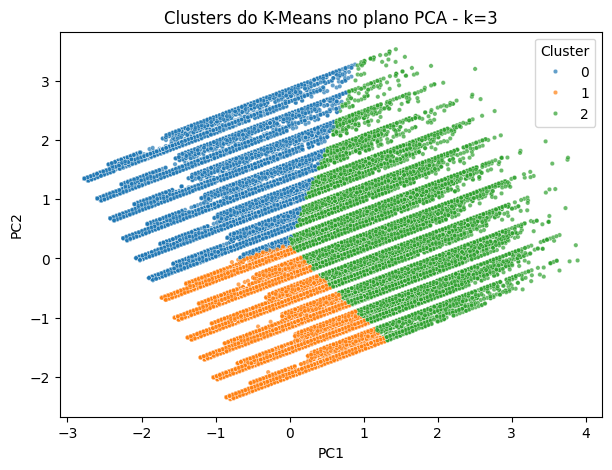

In [14]:
melhor_k = 3

kmeans_final = KMeans(
    n_clusters=melhor_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

df_modelo["CLUSTER_KMEANS"] = kmeans_final.fit_predict(X_pca)

print("\nDistribuição dos clusters do K-Means:")
print(df_modelo["CLUSTER_KMEANS"].value_counts())


plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_modelo["CLUSTER_KMEANS"],
    palette="tab10",
    s=10,
    alpha=0.7
)
plt.title(f"Clusters do K-Means no plano PCA - k={melhor_k}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

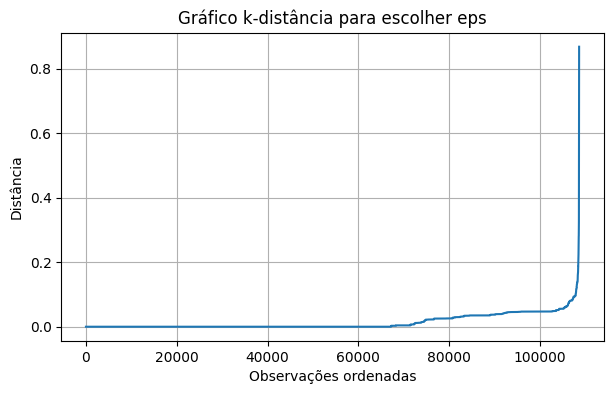

eps: 0.03 | clusters: 1604 | ruído: 21.8 %
eps: 0.05 | clusters: 39 | ruído: 2.93 %
eps: 0.08 | clusters: 23 | ruído: 0.89 %
eps: 0.1 | clusters: 13 | ruído: 0.36 %
eps: 0.15 | clusters: 1 | ruído: 0.15 %
eps: 0.2 | clusters: 1 | ruído: 0.07 %
eps: 0.3 | clusters: 1 | ruído: 0.02 %
eps: 0.4 | clusters: 1 | ruído: 0.0 %
eps: 0.5 | clusters: 1 | ruído: 0.0 %


In [15]:
#----DBSCAN
min_samples = 20

vizinhos = NearestNeighbors(n_neighbors=min_samples)
vizinhos.fit(X_pca)

distancias, indices = vizinhos.kneighbors(X_pca)
k_distancias = np.sort(distancias[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distancias)
plt.title("Gráfico k-distância para escolher eps")
plt.xlabel("Observações ordenadas")
plt.ylabel("Distância")
plt.grid(True)
plt.show()


#---Testando valores de eps para o DBSCAN

valores_eps = [0.03, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

for eps in valores_eps:
    dbscan_teste = DBSCAN(eps=eps, min_samples=min_samples)
    labels_teste = dbscan_teste.fit_predict(X_pca)

    n_clusters = len(set(labels_teste)) - (1 if -1 in labels_teste else 0)
    n_ruido = np.sum(labels_teste == -1)
    perc_ruido = n_ruido / len(labels_teste) * 100

    print(
        "eps:", eps,
        "| clusters:", n_clusters,
        "| ruído:", round(perc_ruido, 2), "%"
    )




Distribuição dos clusters do DBSCAN:
CLUSTER_DBSCAN
 4     16246
 3     15977
 2     14515
 5     14346
 6     11152
 1      9057
 7      8615
 8      5022
 0      3971
 9      3663
 10     2940
 11     2687
-1       396
 12       20
Name: count, dtype: int64


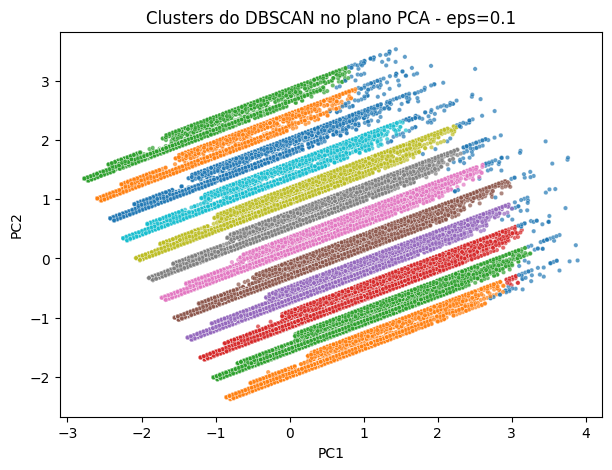

In [16]:
#cluster com os eps escolhidos
eps_escolhido = 0.10

dbscan_final = DBSCAN(
    eps=eps_escolhido,
    min_samples=min_samples
)

df_modelo["CLUSTER_DBSCAN"] = dbscan_final.fit_predict(X_pca)

print("\nDistribuição dos clusters do DBSCAN:")
print(df_modelo["CLUSTER_DBSCAN"].value_counts())


plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_modelo["CLUSTER_DBSCAN"],
    palette="tab10",
    s=10,
    alpha=0.7,
    legend=False
)
plt.title(f"Clusters do DBSCAN no plano PCA - eps={eps_escolhido}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [17]:

#perfil dos clusters

print("\nPerfil de idade por cluster - K-Means:")
print(df_modelo.groupby("CLUSTER_KMEANS")["IDADE"].describe())

print("\nFaixa etária por cluster - K-Means (%):")
print(pd.crosstab(
    df_modelo["CLUSTER_KMEANS"],
    df_modelo["FAIXA_ETARIA"],
    normalize="index"
) * 100)

print("\nSexo por cluster - K-Means (%):")
print(pd.crosstab(
    df_modelo["CLUSTER_KMEANS"],
    df_modelo["SEXO"],
    normalize="index"
) * 100)

print("\nRaça/cor por cluster - K-Means (%):")
print(pd.crosstab(
    df_modelo["CLUSTER_KMEANS"],
    df_modelo["RACA"],
    normalize="index"
) * 100)


print("\nPerfil de idade por cluster - DBSCAN:")
print(df_modelo.groupby("CLUSTER_DBSCAN")["IDADE"].describe())

print("\nFaixa etária por cluster - DBSCAN (%):")
print(pd.crosstab(
    df_modelo["CLUSTER_DBSCAN"],
    df_modelo["FAIXA_ETARIA"],
    normalize="index"
) * 100)

print("\nSexo por cluster - DBSCAN (%):")
print(pd.crosstab(
    df_modelo["CLUSTER_DBSCAN"],
    df_modelo["SEXO"],
    normalize="index"
) * 100)


Perfil de idade por cluster - K-Means:
                  count       mean        std   min   25%   50%   75%    max
CLUSTER_KMEANS                                                              
0               29458.0  23.131781  14.532556   0.0  12.0  23.0  33.0   83.0
1               43320.0  19.989797  11.475047   0.0  10.0  20.0  28.0   50.0
2               35829.0  51.120461  14.322832  25.0  40.0  50.0  60.0  114.0

Faixa etária por cluster - K-Means (%):
FAIXA_ETARIA         0-11      12-17      18-29      30-44      45-59  \
CLUSTER_KMEANS                                                          
0               24.265055  11.745536  32.178016  23.776224   6.819879   
1               27.846260  13.954294  36.394275  20.909511   0.895660   
2                0.000000   0.000000   4.228418  30.670686  38.948896   

FAIXA_ETARIA         60+  
CLUSTER_KMEANS            
0                1.21529  
1                0.00000  
2               26.15200  

Sexo por cluster - K-Means (%):
